# Energy-Based Model with Score Matching and Langevin Sampling

## 1. Data Preparation

We generate a synthetic dataset using the **two moons distribution**.  
This dataset contains two curved clusters and is commonly used to test generative models.

Steps:
- Generate 1000 samples using `make_moons`
- Add small Gaussian noise
- Normalize the data for stable training
- Convert the dataset to a PyTorch tensor

The resulting dataset represents the **true data distribution** we want the model to learn.

---

# 2. Score Network

We train a neural network called **ScoreNet** to estimate the **score function**:

$$
s_\theta(x) = \nabla_x \log p(x)
$$

This score represents the **direction toward regions of higher probability**.

Architecture:
- Input layer: 2 dimensions (x,y)
- Hidden layer: 64 units
- Activation: Softplus
- Hidden layer: 64 units
- Activation: Softplus
- Output layer: 2 dimensions (score vector)

Softplus is used instead of ReLU because it provides **smoother gradients**, which helps when computing second derivatives.

---

# 3. Score Matching Loss (Hyvärinen Loss)

Since we do not know the true probability density $p(x)$, we cannot directly train using likelihood.

Instead we use **Score Matching** which minimizes:

$$
L = \mathbb{E} \left[ \nabla_x \cdot s_\theta(x) + \frac{1}{2} ||s_\theta(x)||^2 \right]
$$

Where:

- $s_\theta(x)$ is the predicted score
- $\nabla_x \cdot s_\theta(x)$ is the **divergence (trace of Jacobian)**

The loss contains two terms:

1. **Divergence term**  
   Encourages the predicted score to match the true score structure.

2. **Norm squared term**  
   Penalizes large score magnitudes.

PyTorch's **autograd** is used to compute these derivatives automatically.

---

# 4. Training the Model

The ScoreNet is trained using the **Adam optimizer**.

Training loop:
1. Compute score predictions
2. Compute score matching loss
3. Backpropagate gradients
4. Update model parameters

Training runs for **1000 iterations**.

During training, the model gradually learns the **structure of the two-moons distribution**.

---

# 5. Visualizing the Learned Score Field

After training, we evaluate the model on a **grid of points** across the space.

The model predicts a **score vector at each grid location**.

These vectors are visualized using a **quiver plot**, showing how the model believes points should move toward higher density regions.

Ideally, arrows should point **toward the moons**.

---

# 6. Langevin Dynamics Sampling

To generate new samples from the learned distribution, we use **Langevin Dynamics**.

The update rule is:

$$
x_{t+1} = x_t + \eta \, s_\theta(x_t) + \sqrt{2\eta} \, \epsilon
$$

Where:

- $s_\theta(x_t)$ is the predicted score
- $\eta$ is the step size
- $\epsilon$ is Gaussian noise

The process consists of:

1. Start from **random noise**
2. Move toward higher probability using the score
3. Add noise to maintain stochastic exploration
4. Repeat for multiple steps

Over time, samples move toward **high density regions of the data distribution**.

---

# 7. Tracking a Langevin Trajectory

To understand how the sampling works, we track the path of a **single particle**.

The trajectory shows:

- Initial random starting point
- Gradual movement guided by the learned score
- Final convergence toward the moon manifold

This trajectory visualizes how **noise + gradient guidance** produces samples from the learned distribution.

---

# 8. Final Visualization

The final plot shows:

- **Orange points** → Real dataset  
- **Red points** → Generated samples  
- **Black line** → Langevin trajectory  
- **Green point** → Starting position  
- **Blue point** → Final sampled position  

If the model has learned correctly, generated samples should align with the **two-moons structure**.

---

# Key Idea

Energy-based models do not explicitly model probability density.

Instead they learn the **score function**:

$$
\nabla_x \log p(x)
$$

This score is then used with **Langevin dynamics** to generate samples.

This concept is the foundation behind **modern diffusion models and score-based generative models**.

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Two Moons Dataset

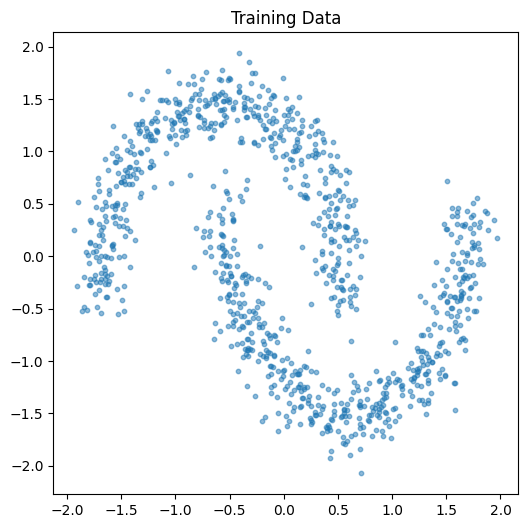

In [2]:
data, _ = make_moons(n_samples=1000, noise=0.1)

data = (data - data.mean(axis=0)) / data.std(axis=0)

dataset = torch.tensor(data, dtype=torch.float32)

plt.figure(figsize=(6,6))
plt.scatter(dataset[:,0], dataset[:,1], s=10, alpha=0.5)
plt.title("Training Data")
plt.show()

# Score Network

In [3]:
class ScoreNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,64),
            nn.Softplus(),
            nn.Linear(64,64),
            nn.Softplus(),
            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.net(x)

# Score Matching Loss

In [4]:
def score_matching_loss(model,x):

    x.requires_grad_(True)

    score_pred = model(x)

    grad_s1 = torch.autograd.grad(
        score_pred[:,0].sum(), x, create_graph=True
    )[0][:,0]

    grad_s2 = torch.autograd.grad(
        score_pred[:,1].sum(), x, create_graph=True
    )[0][:,1]

    trace_jacobian = grad_s1 + grad_s2

    norm_sq = 0.5 * torch.sum(score_pred**2, dim=1)

    loss = trace_jacobian + norm_sq

    return loss.mean()

# Training Score Network

In [5]:
model = ScoreNet()

optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

print("Training...")

for epoch in range(1000):

    optimizer.zero_grad()

    loss = score_matching_loss(model, dataset)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}  Loss {loss.item():.4f}")

Training...
Epoch 0  Loss 0.4965
Epoch 200  Loss -18.7939
Epoch 400  Loss -25.2629
Epoch 600  Loss -30.1308
Epoch 800  Loss -34.5779


# Plotting Training Loss

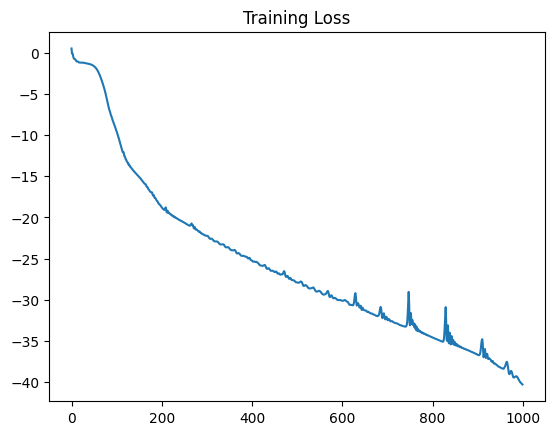

In [6]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.show()

# Visualizing Learnt Field

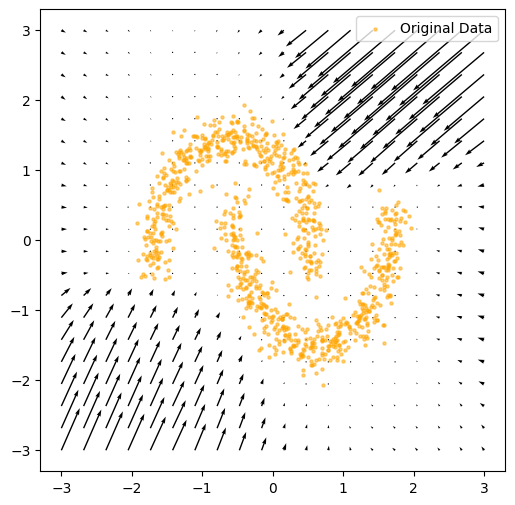

In [7]:
x_range = np.linspace(-3,3,20)
y_range = np.linspace(-3,3,20)

X,Y = np.meshgrid(x_range,y_range)

grid_pts = torch.tensor(
    np.stack([X.ravel(),Y.ravel()],axis=1),
    dtype=torch.float32
)

with torch.no_grad():
    scores = model(grid_pts).numpy()

U = scores[:,0].reshape(X.shape)
V = scores[:,1].reshape(Y.shape)

plt.figure(figsize=(6,6))

plt.quiver(X,Y,U,V)

plt.scatter(dataset.detach()[:,0],
            dataset.detach()[:,1],
            s=5,
            color='orange',
            alpha=0.5,
            label='Original Data')

plt.legend()
plt.show()

# Langevin Sampling

In [22]:
def langevin_sampling(model, n_samples=1000, n_steps=200, eta=0.01):

    x = torch.randn(n_samples,2)

    for _ in range(n_steps):

        x.requires_grad_(True)

        score = model(x)

        noise = torch.randn_like(x)

        x = x + eta * score + np.sqrt(2 * eta) * noise

        x = x.detach()

    return x

In [23]:
samples = langevin_sampling(model)
samples = samples.numpy()

In [24]:
x = torch.randn(1,2)

path = []

for _ in range(200):

    path.append(x.detach().numpy()[0])

    x.requires_grad_(True)

    score = model(x)

    noise = torch.randn_like(x)

    x = x + 0.01 * score + np.sqrt(2 * 0.01) * noise

    x = x.detach()

path = np.array(path)

path_x = path[:,0]
path_y = path[:,1]

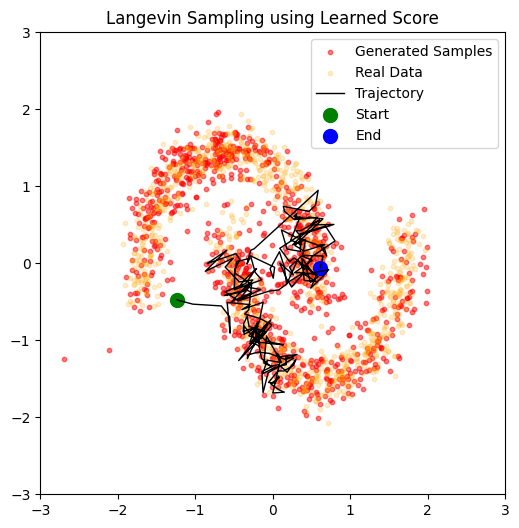

In [27]:
plt.figure(figsize=(6,6))

plt.scatter(samples[:,0], samples[:,1],
            s=10, color='red', alpha=0.5,
            label='Generated Samples')

plt.scatter(dataset.detach()[:,0], dataset.detach()[:,1],
            s=10, color='orange', alpha=0.2,
            label='Real Data')

plt.plot(path_x, path_y,
         color='black', linewidth=1,
         label='Trajectory')

plt.scatter(path_x[0], path_y[0],
            c='green', s=100,
            label='Start')

plt.scatter(path_x[-1], path_y[-1],
            c='blue', s=100,
            label='End')

plt.xlim(-3,3)
plt.ylim(-3,3)

plt.legend()
plt.title("Langevin Sampling using Learned Score")

plt.show()